In [3]:
import pandas as pd
import requests
import numpy as np
import openpyxl
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [5]:
#url de la API

api_url='https://api.yelp.com/v3/businesses/search'

#estos datos corresponden a una cuenta de usuario creada previamente

clientid='GWOCZh9-BmZxtdsAjr7Gug'
apikey='FHVvXoNmTXIl9DuxYis7AV5uLPujm9MLwrhgs5NgvCfaOxd3V6mxt6dQU8eEqYJiGxe816XATx7ufWjbMWqbV-2Uku1jxBJv8BGRC74NroLPl27PDQqs0tDixit-YHYx'
headers={'Authorization':'Bearer %s'%apikey}

In [6]:
ciudad = "Phoenix" # Se puede elegir cualquier ciudad del dataset entregado

In [7]:
# De esta manera se consulta el API de Yelp para obtener información sobre restaurantes en la ciudad especificada

params={'term':'restaurants','location': ciudad,'limit':50}
response=requests.get(api_url,params=params,headers=headers)
data=response.json()
data

{'businesses': [{'id': '9IhbHwzXbhQmt3NtXe7kPA',
   'alias': 'tesota-phoenix-2',
   'name': 'Tesota',
   'image_url': 'https://s3-media0.fl.yelpcdn.com/bphoto/ys-WWfksboP2eWl7v1HQrw/o.jpg',
   'is_closed': False,
   'url': 'https://www.yelp.com/biz/tesota-phoenix-2?adjust_creative=GWOCZh9-BmZxtdsAjr7Gug&utm_campaign=yelp_api_v3&utm_medium=api_v3_business_search&utm_source=GWOCZh9-BmZxtdsAjr7Gug',
   'review_count': 283,
   'categories': [{'alias': 'comfortfood', 'title': 'Comfort Food'},
    {'alias': 'bars', 'title': 'Bars'},
    {'alias': 'pizza', 'title': 'Pizza'}],
   'rating': 4.6,
   'coordinates': {'latitude': 33.50953118911398,
    'longitude': -112.07879800599136},
   'transactions': [],
   'location': {'address1': '300 W Camelback Rd',
    'address2': '',
    'address3': None,
    'city': 'Phoenix',
    'zip_code': '85013',
    'country': 'US',
    'state': 'AZ',
    'display_address': ['300 W Camelback Rd', 'Phoenix, AZ 85013']},
   'phone': '+16029898456',
   'display_phone

In [8]:
# Veamos los keys del diccionario recibido

data.keys()

dict_keys(['businesses', 'total', 'region'])

In [9]:
# El primer elemento del diccionario indica el total de restaurants existentes en la API

print('En total la base de datos registra %d restaurants'%data['total'])

En total la base de datos registra 3000 restaurants


In [10]:
data['businesses'] # Hasta acá se le entregaría a los estudiantes

[{'id': '9IhbHwzXbhQmt3NtXe7kPA',
  'alias': 'tesota-phoenix-2',
  'name': 'Tesota',
  'image_url': 'https://s3-media0.fl.yelpcdn.com/bphoto/ys-WWfksboP2eWl7v1HQrw/o.jpg',
  'is_closed': False,
  'url': 'https://www.yelp.com/biz/tesota-phoenix-2?adjust_creative=GWOCZh9-BmZxtdsAjr7Gug&utm_campaign=yelp_api_v3&utm_medium=api_v3_business_search&utm_source=GWOCZh9-BmZxtdsAjr7Gug',
  'review_count': 283,
  'categories': [{'alias': 'comfortfood', 'title': 'Comfort Food'},
   {'alias': 'bars', 'title': 'Bars'},
   {'alias': 'pizza', 'title': 'Pizza'}],
  'rating': 4.6,
  'coordinates': {'latitude': 33.50953118911398,
   'longitude': -112.07879800599136},
  'transactions': [],
  'location': {'address1': '300 W Camelback Rd',
   'address2': '',
   'address3': None,
   'city': 'Phoenix',
   'zip_code': '85013',
   'country': 'US',
   'state': 'AZ',
   'display_address': ['300 W Camelback Rd', 'Phoenix, AZ 85013']},
  'phone': '+16029898456',
  'display_phone': '(602) 989-8456',
  'distance': 170

## Extracción de datos

Vamos a extraer datos importantes que nos ofrece nuestro código API.

In [11]:
import pandas as pd

negocios = []

for negocio in data['businesses']:
    nombre = negocio['name']               # Nos dará el nombre.
    rating = negocio['rating']             # Nos dará la valoración del restaurante.
    reviews = negocio['review_count']      # Nos dará la cantidad de reseñas.
    
    # categorías 
    categorias = [categorias['title'] for categorias in negocio['categories']]
    
    negocios.append({
        'nombre': nombre,
        'rating': rating,
        'reviews': reviews,
        'categorias': ", ".join(categorias)
    })

df_restaurantes = pd.DataFrame(negocios)

display(df_restaurantes.head(10))

,nombre,rating,reviews,categorias
0,Tesota,4.6,283,"Comfort Food, Bars, Pizza"
1,The Neighborly,4.2,360,New American
2,Aftermath,4.4,452,"New American, Cocktail Bars, Burgers"
3,Vecina,4.7,443,"Latin American, New American"
4,Collagen Dumpling Dynasty,3.9,13,Chinese
5,Windsor,4.3,2006,"New American, Breakfast & Brunch, Cocktail Bars"
6,Mensho Ramen,4.5,215,Ramen
7,Glai Baan,4.6,1519,Thai
8,Buck & Rider,4.4,2348,"Seafood, Breakfast & Brunch, Live/Raw Food"
9,First & Last,4.3,529,"Italian, Cocktail Bars, Sandwiches"


In [12]:
df_restaurantes = pd.DataFrame(data['businesses'])             # Esta es una manera más de ver los datos de cada restaurante, pero más detallado.
display(df_restaurantes.head())

,id,alias,name,image_url,is_closed,url,review_count,categories,rating,coordinates,transactions,location,phone,display_phone,distance,price
0,9IhbHwzXbhQmt3NtXe7kPA,tesota-phoenix-2,Tesota,https://s3-media0.fl.yelpcdn.com/bphoto/ys-WWf...,False,https://www.yelp.com/biz/tesota-phoenix-2?adju...,283,"[{'alias': 'comfortfood', 'title': 'Comfort Fo...",4.6,"{'latitude': 33.50953118911398, 'longitude': -...",[],"{'address1': '300 W Camelback Rd', 'address2':...",+16029898456,(602) 989-8456,1701.334526,NaN
1,gntAovgMJQq_AagCp5Itvw,the-neighborly-phoenix,The Neighborly,https://s3-media0.fl.yelpcdn.com/bphoto/8KplsO...,False,https://www.yelp.com/biz/the-neighborly-phoeni...,360,"[{'alias': 'newamerican', 'title': 'New Americ...",4.2,"{'latitude': 33.517967756368094, 'longitude': ...",[],"{'address1': '5538 N 7th St', 'address2': None...",+16026751852,(602) 675-1852,266.356048,$$
2,vDJH-TXi-dVdBg8wv8VRTA,aftermath-phoenix-6,Aftermath,https://s3-media0.fl.yelpcdn.com/bphoto/kvr999...,False,https://www.yelp.com/biz/aftermath-phoenix-6?a...,452,"[{'alias': 'newamerican', 'title': 'New Americ...",4.4,"{'latitude': 33.524016, 'longitude': -112.048413}","[delivery, pickup]","{'address1': '1534 E Bethany Home Rd', 'addres...",+16026075240,(602) 607-5240,1665.266821,$$
3,rh6yL-dxvCEo-bJk_UTE7w,vecina-phoenix,Vecina,https://s3-media0.fl.yelpcdn.com/bphoto/EGieqF...,False,https://www.yelp.com/biz/vecina-phoenix?adjust...,443,"[{'alias': 'latin', 'title': 'Latin American'}...",4.7,"{'latitude': 33.488594, 'longitude': -111.960359}",[],"{'address1': '3433 N 56th St', 'address2': Non...",+16026752000,(602) 675-2000,10396.272555,$$
4,1W6VX1ZydgOlNe8n4itoVQ,collagen-dumpling-dynasty-phoenix,Collagen Dumpling Dynasty,https://s3-media0.fl.yelpcdn.com/bphoto/VNYMzY...,False,https://www.yelp.com/biz/collagen-dumpling-dyn...,13,"[{'alias': 'chinese', 'title': 'Chinese'}]",3.9,"{'latitude': 33.51456204359754, 'longitude': -...",[],"{'address1': '5241 N 16th St', 'address2': 'Un...",,,1835.605296,NaN


In [13]:
import pandas as pd 

df_clientes = pd.read_csv('base_datos_restaurantes_USA_v2.csv')

# Antes de empezar, traemos nuestro DataFrame con los datos de los restaurantes.

In [14]:
df_phoenix = df_clientes[df_clientes["ciudad_residencia"] == "Phoenix"]

# Ahora usamos un comando que nos filtre a los clientes según su ciudad de residencia.

In [15]:
df_phoenix['preferencias_alimenticias'].value_counts()

# Como se puede observar, estamos filtrando las preferencias alimenticias de los clientes de los restaurantes de Phoenix.

preferencias_alimenticias
Carnes         416
Vegetariano    301
Mariscos       209
Pescado        200
Vegano         155
Otro           154
Name: count, dtype: int64

In [16]:
display(df_phoenix.columns.tolist())                          # Corroboro que los DataFrame y sus nombres estén correcctos.
display(df_restaurantes.columns.tolist())

['id_persona',
 'nombre',
 'apellido',
 'edad',
 'genero',
 'ciudad_residencia',
 'estrato_socioeconomico',
 'frecuencia_visita',
 'promedio_gasto_comida',
 'ocio',
 'consume_licor',
 'preferencias_alimenticias',
 'membresia_premium',
 'telefono_contacto',
 'correo_electronico',
 'tipo_de_pago_mas_usado',
 'ingresos_mensuales']

['id',
 'alias',
 'name',
 'image_url',
 'is_closed',
 'url',
 'review_count',
 'categories',
 'rating',
 'coordinates',
 'transactions',
 'location',
 'phone',
 'display_phone',
 'distance',
 'price']

In [17]:
print('-- Tabla Pivote de preferencias alimenticias por género --')

df_phoenix.pivot_table(index='genero', columns='preferencias_alimenticias', values = 'id_persona', aggfunc='count', fill_value = 0)

# Lo volcamos en una tabla pivote para mejor lectura. 

-- Tabla Pivote de preferencias alimenticias por género --


preferencias_alimenticias,Carnes,Mariscos,Otro,Pescado,Vegano,Vegetariano
genero,,,,,,
Femenino,204,97,78,104,74,149
Masculino,212,112,76,96,81,152


In [18]:
df_restaurantes  = pd.json_normalize(
    data['businesses'],
    record_path = 'categories',
    meta = ['name', 'review_count', 'rating', 'price'],
    sep = '_',
    errors= 'ignore')

# para filtrar por alias, nombre, reseñas, rating, etc.

display(df_restaurantes.head(10))

,alias,title,name,review_count,rating,price
0,comfortfood,Comfort Food,Tesota,283,4.6,NaN
1,bars,Bars,Tesota,283,4.6,NaN
2,pizza,Pizza,Tesota,283,4.6,NaN
3,newamerican,New American,The Neighborly,360,4.2,$$
4,newamerican,New American,Aftermath,452,4.4,$$
5,cocktailbars,Cocktail Bars,Aftermath,452,4.4,$$
6,burgers,Burgers,Aftermath,452,4.4,$$
7,latin,Latin American,Vecina,443,4.7,$$
8,newamerican,New American,Vecina,443,4.7,$$
9,chinese,Chinese,Collagen Dumpling Dynasty,13,3.9,NaN


## Diccionarios.

Vamos a crearlos en base a las preferencias alimenticias de los clientes, para poder compararlas con las categorías de los restaurantes y así poder recomendar cuál convendría según su preferencia. 

In [20]:
df_restaurantes['alias'].unique()             # Lo que haremos con nuestros datos será ver todas las categorías disponibles y clasficarlas.

<StringArray>
[     'comfortfood',             'bars',            'pizza',
      'newamerican',     'cocktailbars',          'burgers',
            'latin',          'chinese', 'breakfast_brunch',
            'ramen',             'thai',          'seafood',
         'raw_food',          'italian',       'sandwiches',
     'tradamerican',            'cafes',    'mediterranean',
              'bbq',        'wine_bars',       'gastropubs',
            'steak',         'southern',            'salad',
       'newmexican',          'beerbar',      'whiskeybars',
           'venues',         'hawaiian',        'caribbean',
         'tikibars',      'asianfusion',         'desserts',
    'beer_and_wine',       'foodtrucks',          'mexican',
           'coffee',            'tapas',       'fishnchips',
           'diners',    'chicken_wings']
Length: 41, dtype: str

In [1]:
categorias_restaurantes = {
    'Carnes': ['bbq', 'steak', 'burgers', 'tradamerican', 'newamerican', 'southern'],
    'Vegetariano': ['vegetarian', 'salad', 'mediterranean', 'cafes'],
    'Mariscos': ['seafood'],
    'Pescado': ['fishnchips'],
    'Vegano': ['vegan', 'raw_food'],

    'Otro': [
        'comfortfood', 'bars', 'pizza', 'cocktailbars', 'chinese',
        'italian', 'sandwiches', 'breakfast_brunch', 'ramen',
        'coffee', 'thai', 'latin', 'wine_bars', 'desserts',
        'newmexican', 'beerbar', 'whiskeybars', 'venues',
        'hawaiian', 'caribbean', 'tikibars', 'delis',
        'gastropubs', 'diners', 'asianfusion', 'mexican',
        'bakeries', 'french']
}

In [42]:
recomendaciones = []

for categoria, alias_list in categorias_restaurantes.items():
    df_recomendacion = df_restaurantes[df_restaurantes['alias'].isin(alias_list)]

    if not df_recomendacion.empty:
        df_top = df_recomendacion.sort_values(by='rating', ascending=False).head(1)
        print(f"Categoría: {categoria}")
        display(df_top)
        recomendaciones.append(df_top)
    else:
        print(f"Categoría: {categoria} -> sin resultados")

    

Categoría: Carnes


,alias,title,name,review_count,rating,price
40,steak,Steakhouses,Pretty Penny,86,4.9,NaN


Categoría: Vegetariano


,alias,title,name,review_count,rating,price
24,cafes,Cafes,Matilda's All Day Cafe,39,4.8,$$


Categoría: Mariscos


...

,alias,title,name,review_count,rating,price
115,fishnchips,Fish & Chips,The Kettle Black Kitchen & Pub,1528,4.3,$$


Categoría: Vegano


,alias,title,name,review_count,rating,price
17,raw_food,Live/Raw Food,Buck & Rider,2348,4.4,$$$


Categoría: Otro


,alias,title,name,review_count,rating,price
38,cocktailbars,Cocktail Bars,Pretty Penny,86,4.9,NaN


In [45]:
recomendaciones = []

for categoria, alias_list in categorias_restaurantes.items():
    df_filtrado = df_restaurantes[df_restaurantes['alias'].isin(alias_list)]

    if not df_filtrado.empty:
        df_top = df_filtrado.sort_values(
            by=['rating', 'review_count'],
            ascending=False
        ).head(1).copy()

        df_top['preferencias_alimenticias'] = categoria
        recomendaciones.append(df_top)

df_recomendacion = pd.concat(recomendaciones, ignore_index=True)

In [48]:
df_clientes_recomendados = df_phoenix.merge(
    df_recomendacion[['preferencias_alimenticias', 'name', 'alias', 'rating', 'review_count']],
    left_on='preferencias_alimenticias',
    right_on='preferencias_alimenticias',
    how='left'
)

display(df_clientes_recomendados.head())

# Con esto, podremos recomendar un restaurante a cada cliente, segun sus preferencias alimenticias.

,id_persona,nombre,apellido,edad,genero,ciudad_residencia,estrato_socioeconomico,frecuencia_visita,promedio_gasto_comida,ocio,consume_licor,preferencias_alimenticias,membresia_premium,telefono_contacto,correo_electronico,tipo_de_pago_mas_usado,ingresos_mensuales,name,alias,rating,review_count
0,8037389869,Kelly,Kidd,37.0,Femenino,Phoenix,Muy Alto,8,47.07,Sí,Sí,Vegetariano,Sí,NaN,NaN,Efectivo,12478,Matilda's All Day Cafe,cafes,4.8,39
1,1679935518,Mary,Rubio,48.0,Femenino,Phoenix,Alto,4,47.55,Sí,No,Vegano,Sí,NaN,NaN,Tarjeta,8914,Buck & Rider,raw_food,4.4,2348
2,9829994892,Katherine,Wilson,34.0,Femenino,Phoenix,Alto,5,28.16,No,No,Carnes,Sí,NaN,jamesray@example.com,Efectivo,5106,Pretty Penny,steak,4.9,86
3,5209858423,Nicole,Little,28.0,Femenino,Phoenix,Alto,5,67.73,Sí,Sí,Vegetariano,No,NaN,NaN,Efectivo,7240,Matilda's All Day Cafe,cafes,4.8,39
4,5788836147,Melissa,Cox,37.0,Femenino,Phoenix,Alto,6,40.76,Sí,No,Vegetariano,Sí,NaN,jameschavez@example.org,Efectivo,4323,Matilda's All Day Cafe,cafes,4.8,39


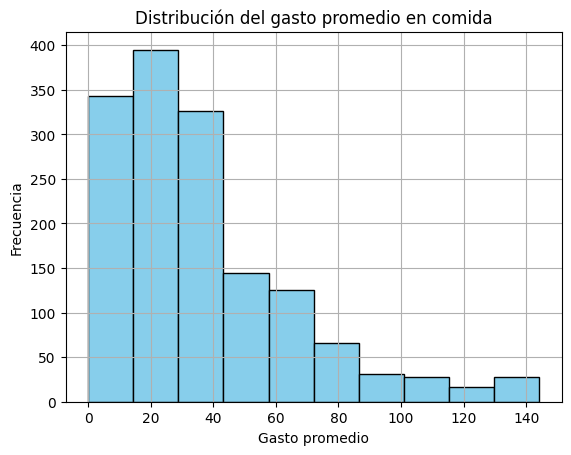

In [53]:
import matplotlib.pyplot as plt

# Vamos a crear un histograma, donde el eje X representará el gasto promedio de los clientes, y el eje Y mostrará la frecuencia de esos gastos.

df_phoenix['promedio_gasto_comida'].hist(color='skyblue', edgecolor='black')

plt.title('Distribución del gasto promedio en comida')
plt.xlabel('Gasto promedio')
plt.ylabel('Frecuencia')

plt.show()